### Model Training
#### This notebook is to train each model and evaluate which one is the best using MLFlow
#### Firstly load data and model from notebook 2

In [2]:
import numpy as np
import joblib
import pandas as pd
from imblearn.over_sampling import SMOTE  
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Load the preprocessed data from .npy files
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')
network_dataset_encoder = joblib.load('../models/label_encoder.pkl')
network_dataset_scaler = joblib.load('../models/network_dataset_scaler.pkl')

# Test the shapes of the loaded data
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

# Test y_train distribution

print('y_train distribution:')
print(pd.Series(network_dataset_encoder.inverse_transform(y_train)).value_counts())

# Test the statistics of X_train
print(f'Mean: {X_train.mean():.4f}')
print(f'Std: {X_train.std():.4f}')
print(f'Min: {X_train.min():.4f}')
print(f'Max: {X_train.max():.4f}')

X_train shape: (2016638, 51)
X_test shape: (504160, 51)
y_train shape: (2016638,)
y_test shape: (504160,)
y_train distribution:
BENIGN                        1676045
DoS Hulk                       138277
DDoS                           102411
PortScan                        72555
DoS GoldenEye                    8229
FTP-Patator                      4745
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1558
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - Sql Injection         17
Heartbleed                          9
Name: count, dtype: int64
Mean: -0.0000
Std: 1.0000
Min: -1293.9682
Max: 1164.5381


/opt/anaconda3/envs/anomaly-detector/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/anomaly-detector/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/anomaly-detector/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from versio

I will now look at applying SMOTE to attacks that are balanced below 1000 readings as this is the natural gap and bring them up to the next natural gap of 1558
I have used the k_neighbours of 8 as the lowest class being 9

In [3]:
# Attacks distribution before SMOTE
print('y_train distribution before SMOTE:')
print(pd.Series(network_dataset_encoder.inverse_transform(y_train)).value_counts())

# Get value counts of the encoded labels
class_distribution = pd.Series(y_train).value_counts().sort_index()


# Create sampling strategy: bring minority classes up to 1558
sampling_threshold = 1000
sampling_target = 1558
sampling_strat = {}
for label, count in class_distribution.items():
    if count < sampling_threshold:
        sampling_strat[label] = sampling_target




smote = SMOTE(random_state=42, k_neighbors=8, sampling_strategy=sampling_strat)  # Adjust k_neighbors based on the number of samples in the minority class

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)



# Attacks distribution after SMOTE
print('y_train distribution after SMOTE:')
print(pd.Series(network_dataset_encoder.inverse_transform(y_train_resampled)).value_counts())

print(f'X_train_resampled shape: {X_train_resampled.shape}')
print(f'y_train_resampled shape: {y_train_resampled.shape}')

np.save('../data/processed/X_train_resampled.npy', X_train_resampled)
np.save('../data/processed/y_train_resampled.npy', y_train_resampled)

y_train distribution before SMOTE:
BENIGN                        1676045
DoS Hulk                       138277
DDoS                           102411
PortScan                        72555
DoS GoldenEye                    8229
FTP-Patator                      4745
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1558
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - Sql Injection         17
Heartbleed                          9
Name: count, dtype: int64
y_train distribution after SMOTE:
BENIGN                        1676045
DoS Hulk                       138277
DDoS                           102411
PortScan                        72555
DoS GoldenEye                    8229
FTP-Patator                      4745
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                    

Now to start fitting the models to compare results - firstly RandomForestClassifier

In [4]:
# Train the Random Forest Classifier
network_dataset_rfc = RandomForestClassifier(n_estimators=100, random_state=42)
network_dataset_rfc.fit(X_train_resampled, y_train_resampled)
joblib.dump(network_dataset_rfc, '../models/network_dataset_rfc.pkl')

# Evaluate the classifier on the test set
y_pred_rfc = network_dataset_rfc.predict(X_test)

# Calculate and print evaluation metrics
print('Random Forest Classifier trained and saved successfully.')
print("Classifier performance on the test set:  ")
f1_score_macro_rfc = f1_score(y_test, y_pred_rfc, average='macro')
classification_rep_rfc = classification_report(y_test, y_pred_rfc, target_names=network_dataset_encoder.classes_)
conf_matrix_rfc = confusion_matrix(y_test, y_pred_rfc)
print(f'F1 Score (Macro): {f1_score_macro_rfc:.4f}')
print('Classification Report:')
print(classification_rep_rfc)
print('Confusion Matrix:')
print(conf_matrix_rfc)




Random Forest Classifier trained and saved successfully.
Classifier performance on the test set:  
F1 Score (Macro): 0.8785
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.89      0.76      0.82       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      0.99      0.99     18139
               SSH-Patator       1.0

First I will save the reports for MLFlow

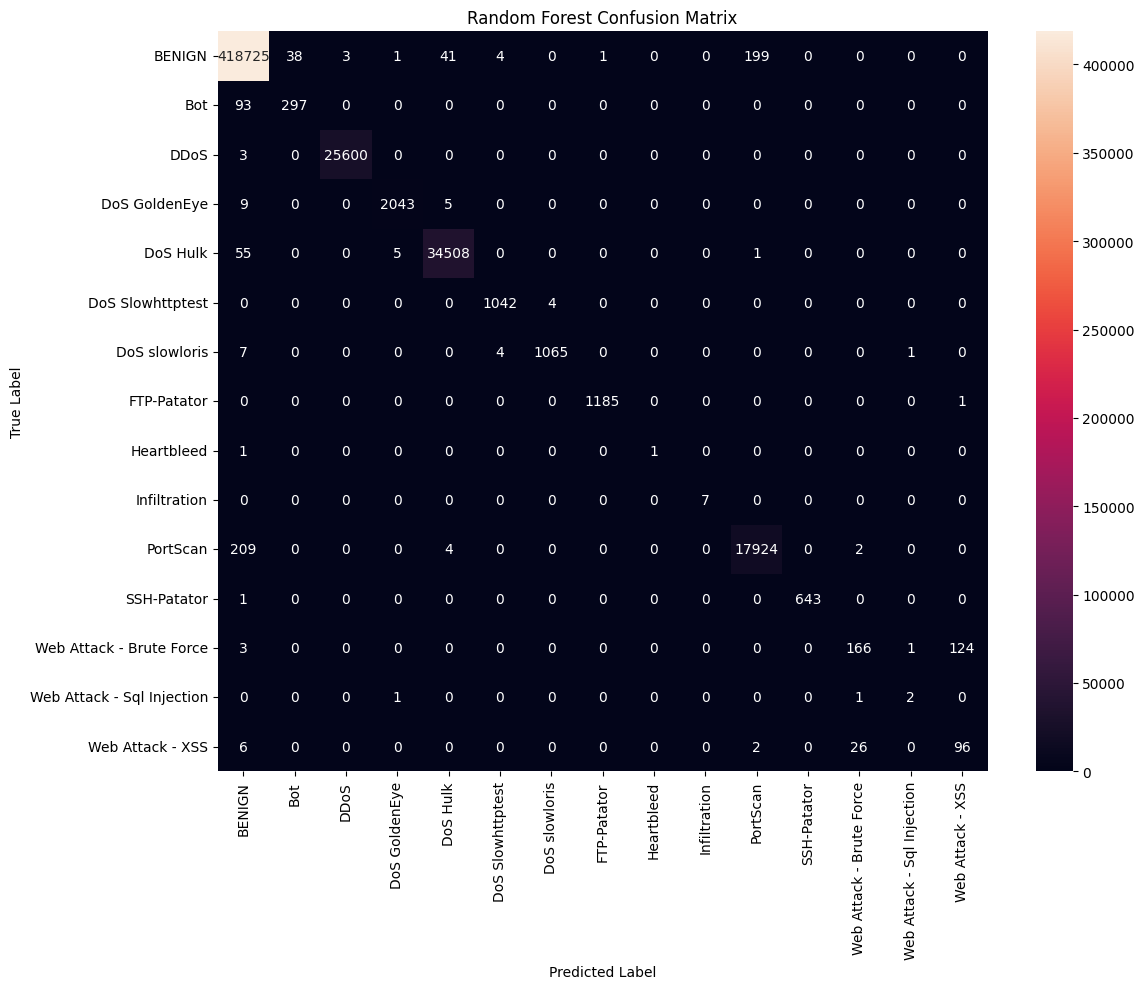

In [8]:
# Confusion matrix as an image
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../reports", exist_ok=True)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_rfc, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/rf_confusion_matrix.png')


with open('../reports/classification_report_rfc.txt', 'w') as f:
    f.write(classification_rep_rfc)

Heartbleed (n=2) and Web Attack - SQL Injection (n=4) have insufficient test samples for reliable metric interpretation. Results for these classes should be treated as indicative only.
Implmenting MLFlow for the RFC model

In [10]:

# Log the model and metrics to MLflow
import mlflow

report_dict_rfc = classification_report(y_test, y_pred_rfc, output_dict=True)

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="random_forest_baseline",):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("f1_macro", f1_score_macro_rfc)
    mlflow.log_metric("recall", report_dict_rfc['macro avg']['recall'])
    mlflow.log_metric("precision", report_dict_rfc['macro avg']['precision'])
    mlflow.log_artifact("../reports/classification_report_rfc.txt")
    mlflow.log_artifact("../reports/rf_confusion_matrix.png")
    mlflow.sklearn.log_model(network_dataset_rfc, name="model")


2026/04/04 15:49:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [11]:
mlflow.end_run()

I will now laod and fit XGBoost model as the 2nd model to compare throughout each mdoel

In [13]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y = y_train)
network_dataset_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', objective='multi:softmax', num_class=len(network_dataset_encoder.classes_))
network_dataset_xgb.fit(X_train, y_train, sample_weight=sample_weights)
joblib.dump(network_dataset_xgb, '../models/network_dataset_xgb.pkl')



['../models/network_dataset_xgb.pkl']

In [14]:
y_pred_xgb = network_dataset_xgb.predict(X_test)

# Calculate and print evaluation metrics
print('XGBoost Classifier trained and saved successfully.')
print("Classifier performance on the test set:  ")
f1_score_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')
classification_report_xgb = classification_report(y_test, y_pred_xgb, target_names=network_dataset_encoder.classes_)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f'F1 Score (Macro): {f1_score_macro_xgb:.4f}')
print('Classification Report:')
print(classification_report_xgb)
print('Confusion Matrix:')
print(conf_matrix_xgb)

XGBoost Classifier trained and saved successfully.
Classifier performance on the test set:  
F1 Score (Macro): 0.9036
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.68      0.99      0.81       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      1.00      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00     

In [15]:
print("Unique predicted classes:", np.unique(y_pred_xgb))
print("Predicted class distribution:")
print(pd.Series(network_dataset_encoder.inverse_transform(y_pred_xgb)).value_counts())

Unique predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Predicted class distribution:
BENIGN                        418531
DoS Hulk                       34608
DDoS                           25614
PortScan                       18336
DoS GoldenEye                   2078
FTP-Patator                     1187
DoS slowloris                   1080
DoS Slowhttptest                1055
SSH-Patator                      645
Bot                              573
Web Attack - Brute Force         304
Web Attack - XSS                 133
Web Attack - Sql Injection         7
Infiltration                       7
Heartbleed                         2
Name: count, dtype: int64


XGBoost was trained on the original imbalanced training data using compute_sample_weight(class_weight='balanced') to handle class imbalance, rather than the SMOTE-resampled data used for Random Forest. This means the two models are not directly comparable on identical training data — a limitation worth noting when interpreting the results. Sample weighting is a valid alternative to oversampling and is native to XGBoost's training process.

Now adding to MLFlow

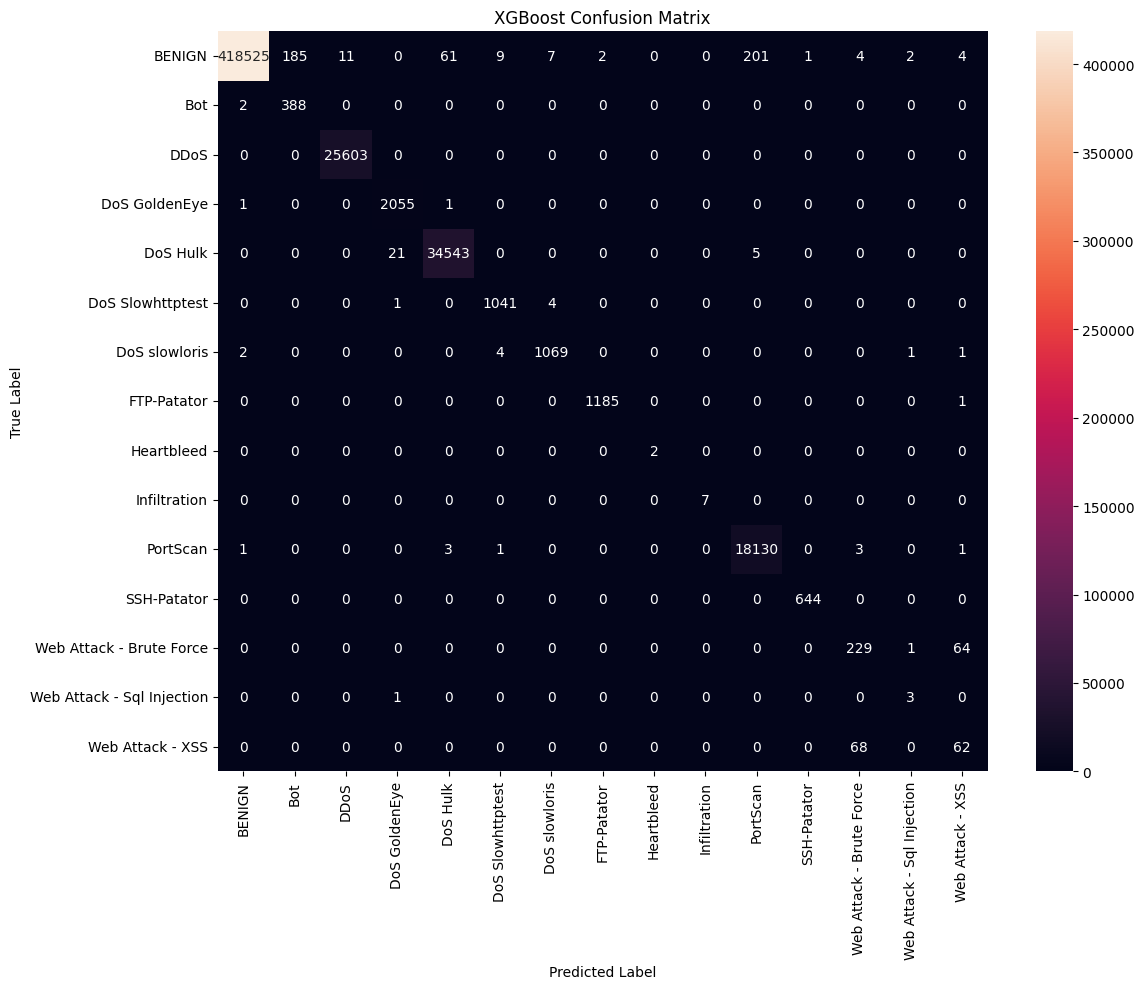

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('XGBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/xgb_confusion_matrix.png')


with open('../reports/classification_report_xgb.txt', 'w') as f:
    f.write(classification_report_xgb)

In [17]:
report_dict_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="XGBoost_baseline",):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("f1_macro", f1_score_macro_xgb)
    mlflow.log_metric("recall", report_dict_xgb['macro avg']['recall'])
    mlflow.log_metric("precision", report_dict_xgb['macro avg']['precision'])
    mlflow.log_artifact("../reports/classification_report_xgb.txt")
    mlflow.log_artifact("../reports/xgb_confusion_matrix.png")
    mlflow.sklearn.log_model(network_dataset_xgb, name="model")

2026/04/04 15:52:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost classifier has nwo been fitted saved, evaluated and uploaded to MLFlow. It was trained using the original X and y due to having bad readings using synthetic SMOTE data i will now reevaluate the RFC model using the same method for fair comparison

In [18]:
# Train the Random Forest Classifier
network_dataset_rfc_02= RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
network_dataset_rfc_02.fit(X_train, y_train)
joblib.dump(network_dataset_rfc_02, '../models/network_dataset_rfc_02.pkl')

# Evaluate the classifier on the test set
y_pred_rfc_02 = network_dataset_rfc_02.predict(X_test)

# Calculate and print evaluation metrics
print('Random Forest Classifier 2nd variation trained and saved successfully.')
print("Classifier performance on the test set:  ")
f1_score_macro_rfc_02 = f1_score(y_test, y_pred_rfc_02, average='macro')
classification_rep_rfc_02 = classification_report(y_test, y_pred_rfc_02, target_names=network_dataset_encoder.classes_)
conf_matrix_rfc_02 = confusion_matrix(y_test, y_pred_rfc_02)
print(f'F1 Score (Macro): {f1_score_macro_rfc_02:.4f}')
print('Classification Report:')
print(classification_rep_rfc_02)
print('Confusion Matrix:')
print(conf_matrix_rfc_02)

Random Forest Classifier 2nd variation trained and saved successfully.
Classifier performance on the test set:  
F1 Score (Macro): 0.8695
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.78      0.88      0.83       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      0.99      0.99     18139
               SSH-Pat

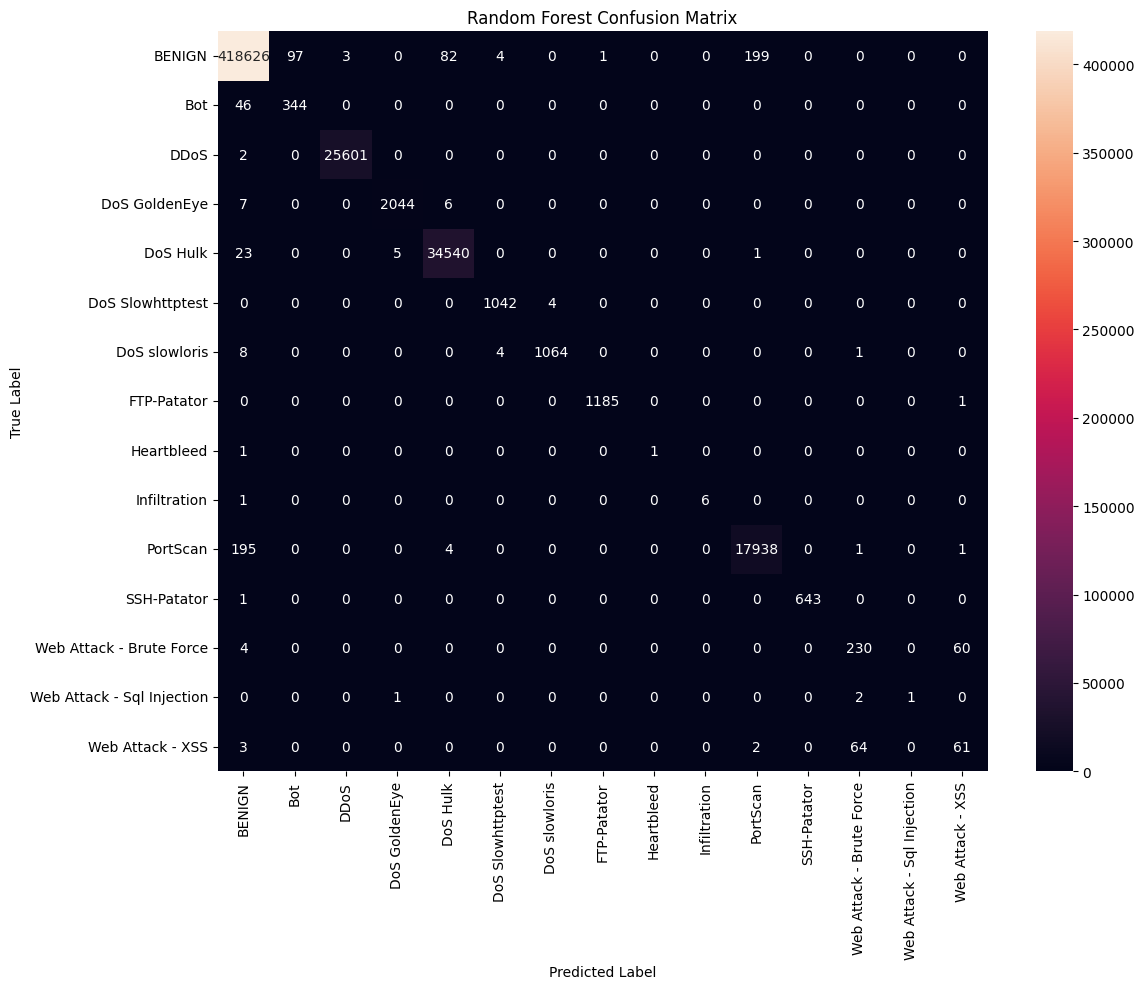

In [19]:
# Confusion matrix as an image
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_rfc_02, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/rf_confusion_matrix_02.png')


with open('../reports/classification_report_rfc_02.txt', 'w') as f:
    f.write(classification_rep_rfc_02)

In [20]:
# Log the model and metrics to MLflow
import mlflow

report_dict_rfc_02 = classification_report(y_test, y_pred_rfc_02, output_dict=True)

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="random_forest_baseline_v2_sample_weighted",):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("f1_macro", f1_score_macro_rfc_02)
    mlflow.log_metric("recall", report_dict_rfc_02['macro avg']['recall'])
    mlflow.log_metric("precision", report_dict_rfc_02['macro avg']['precision'])
    mlflow.log_artifact("../reports/classification_report_rfc_02.txt")
    mlflow.log_artifact("../reports/rf_confusion_matrix_02.png")
    mlflow.sklearn.log_model(network_dataset_rfc_02, name="model")

2026/04/04 15:57:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## Random Forest v2 - Class Weighted

A second Random Forest variant trained on the original imbalanced data using `class_weight='balanced'` 
to allow direct comparison with XGBoost on identical training data. This approach assigns higher 
penalty to misclassifications of minority classes during training rather than generating synthetic samples.

**Key decision:** Using `class_weight='balanced'` over SMOTE here aligns the imbalance handling strategy 
with XGBoost, enabling a fair head-to-head comparison. RF v1 (SMOTE) is retained separately to 
demonstrate the effect of oversampling vs class weighting on the same model architecture.

---

## Deep Neural Network (Keras)

A deep learning baseline using TensorFlow/Keras. While tree-based models excel on tabular data, 
a DNN demonstrates the ability to learn complex non-linear feature interactions and serves as a 
comparison point against the ensemble methods above.

**Architecture:**
- Input layer: 51 features
- Hidden layers: Dense layers with ReLU activation and Dropout regularisation
- Output layer: 15 neurons with Softmax activation (one per class)
- Loss function: `sparse_categorical_crossentropy` (handles integer-encoded labels natively)
- Optimiser: Adam

**Imbalance handling:** `sample_weight` computed via `compute_sample_weight('balanced')` 
to match XGBoost's approach and enable direct comparison.

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_sample_weight
from tensorflow.keras.callbacks import EarlyStopping

# Define the neural network architecture
network_dataset_tf = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(len(network_dataset_encoder.classes_), activation='softmax')
])

# Compile the model
network_dataset_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
                           metrics=['accuracy'])

print(network_dataset_tf.summary())



/opt/anaconda3/envs/anomaly-detector/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,487 (68.31 KB)

 Trainable params: 17,487 (68.31 KB)

 Non-trainable params: 0 (0.00 B)

None


In [22]:
# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # Add early stopping to prevent overfitting
sample_weights = compute_sample_weight(class_weight='balanced', y = y_train)
network_dataset_tf_history = network_dataset_tf.fit(X_train, y_train, epochs=20, batch_size=512, validation_split=0.2, sample_weight=sample_weights, callbacks=[early_stopping]) # Add class_weight to handle class imbalance

Epoch 1/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5767 - loss: 1.9736 - val_accuracy: 0.6488 - val_loss: 0.8451
Epoch 2/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6358 - loss: 0.9577 - val_accuracy: 0.7190 - val_loss: 0.5930
Epoch 3/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6576 - loss: 0.7309 - val_accuracy: 0.7007 - val_loss: 0.5725
Epoch 4/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6887 - loss: 0.6470 - val_accuracy: 0.7175 - val_loss: 0.4768
Epoch 5/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7022 - loss: 0.7559 - val_accuracy: 0.7293 - val_loss: 0.4366
Epoch 6/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7148 - loss: 0.5452 - val_accuracy: 0.7249 - val_loss: 0.4308
Epoch 7/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7149 - loss: 0.6148 - val_accuracy: 0.7503 - val_loss: 0.3722
Epoch 8/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7288 - loss: 0.7172 - 

In [23]:
# Evaluate the model on the test set
y_pred_tf = network_dataset_tf.predict(X_test)
y_pred_tf = np.argmax(y_pred_tf, axis=1)  # convert probabilities to class labels

#Save the model
network_dataset_tf.save('../models/network_dataset_tf.h5')

15755/15755 ━━━━━━━━━━━━━━━━━━━━ 3s 161us/step


Neural Network Classifier trained successfully.
Classifier performance on the test set:  
F1 Score (Macro): 0.3634
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.72      0.84    419012
                       Bot       0.01      0.95      0.02       390
                      DDoS       0.63      1.00      0.77     25603
             DoS GoldenEye       0.51      0.93      0.66      2057
                  DoS Hulk       0.87      0.94      0.90     34569
          DoS Slowhttptest       0.32      0.98      0.48      1046
             DoS slowloris       0.15      0.94      0.25      1077
               FTP-Patator       0.15      1.00      0.26      1186
                Heartbleed       0.02      0.50      0.04         2
              Infiltration       0.00      1.00      0.00         7
                  PortScan       0.65      0.99      0.78     18139
               SSH-Patator       0.15      0.

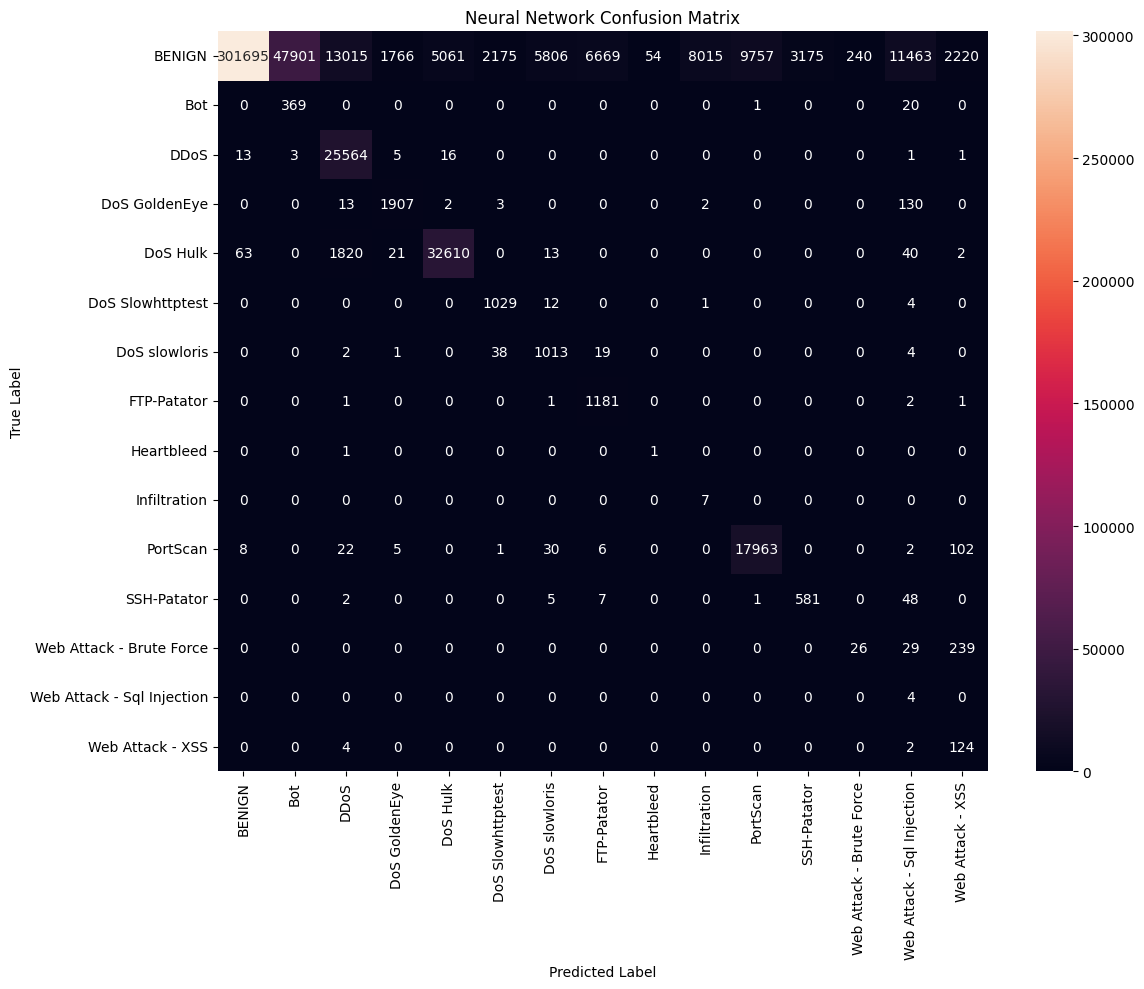

In [24]:
# Evaluate the model
print('Neural Network Classifier trained successfully.')
print("Classifier performance on the test set:  ")
f1_score_macro_tf = f1_score(y_test, y_pred_tf, average='macro')
classification_report_tf = classification_report(y_test, y_pred_tf, target_names=network_dataset_encoder.classes_)
conf_matrix_tf = confusion_matrix(y_test, y_pred_tf)
print(f'F1 Score (Macro): {f1_score_macro_tf:.4f}')
print('Classification Report:')
print(classification_report_tf)
print('Confusion Matrix:')
print(conf_matrix_tf)
# Confusion matrix as an image
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_tf, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('Neural Network Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/tf_confusion_matrix.png')


with open('../reports/classification_report_tf.txt', 'w') as f:
    f.write(classification_report_tf)


DNNs underperform tree-based models on structured tabular network flow data. This is consistent with the literature and validates XGBoost as the production candidate.

In [25]:
report_dict_tf = classification_report(y_test, y_pred_tf, output_dict=True)

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="Keras_TensorFlow",):
    
    mlflow.log_metric("f1_macro", f1_score_macro_tf)
    mlflow.log_param("epochs", 20)
    mlflow.log_param("batch_size", 512)
    mlflow.log_param("architecture", "128-64-32")
    mlflow.log_metric("recall", report_dict_tf['macro avg']['recall'])
    mlflow.log_metric("precision", report_dict_tf['macro avg']['precision'])
    mlflow.log_artifact("../reports/classification_report_tf.txt")
    mlflow.log_artifact("../reports/tf_confusion_matrix.png")
    mlflow.sklearn.log_model(network_dataset_tf, name="model")

2026/04/04 15:59:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


#### Model Comparison

In [27]:
# Create an tabel comapring the results of the three models
results_df = pd.DataFrame({
    'Model': ['Random Forest (SMOTE)', 'XGBoost (Class Weight)','Random Forest (Class Weight)', 'Neural Network (Class Weight)'],
    'F1 Score (Macro)': [f1_score_macro_rfc, f1_score_macro_xgb, f1_score_macro_rfc_02, f1_score_macro_tf],
    'Recall (Macro Avg)': [report_dict_rfc['macro avg']['recall'], report_dict_xgb['macro avg']['recall'], report_dict_rfc_02['macro avg']['recall'], report_dict_tf['macro avg']['recall']],
    'Precision (Macro Avg)': [report_dict_rfc['macro avg']['precision'], report_dict_xgb['macro avg']['precision'], report_dict_rfc_02['macro avg']['precision'], report_dict_tf['macro avg']['precision']]
})

print(results_df)

                           Model  F1 Score (Macro)  Recall (Macro Avg)  \
0          Random Forest (SMOTE)          0.878532            0.868403   
1         XGBoost (Class Weight)          0.903646            0.932285   
2   Random Forest (Class Weight)          0.869550            0.846881   
3  Neural Network (Class Weight)          0.363421            0.859328   

   Precision (Macro Avg)  
0               0.909533  
1               0.884923  
2               0.934537  
3               0.306626  


## Model Comparison Summary

| Model | F1 Macro | Precision | Recall |
|-------|----------|-----------|--------|
| Random Forest (SMOTE) | 0.8785 | 0.9095 | 0.8684 |
| XGBoost (sample_weight) | 0.9036 | 0.8849 | 0.9323 |
| Random Forest (class_weight) | 0.8696 | 0.9345 | 0.8469 |
| Keras DNN (sample_weight) | 0.3634 | 0.3066 | 0.8593 |

### Key Findings

**XGBoost is the strongest performer** across all meaningful metrics, achieving the highest macro F1 
(0.9036) and highest recall (0.9323). In a network intrusion detection context, recall is the 
critical metric — a missed attack (false negative) is significantly more costly than a false alarm. 
XGBoost is therefore selected as the production candidate.

**Random Forest variants performed comparably**, with marginal differences depending on imbalance 
handling strategy. SMOTE improved recall slightly at the cost of some precision; class weighting 
produced the inverse. Neither approach was conclusively superior, suggesting the model architecture 
is more important than the imbalance handling method for this dataset.

**The Keras DNN significantly underperformed** the tree-based models, achieving a macro F1 of only 
0.3634 despite reasonable recall. Precision of 0.31 indicates excessive false positives — the model 
overcorrects for class imbalance and misclassifies a substantial proportion of BENIGN traffic as 
attacks. This is consistent with the well-documented tendency of DNNs to underperform tree-based 
models on structured tabular data.

**Persistent weak points across all models** were the Web Attack classes (XSS, Brute Force, SQL 
Injection), which consistently showed lower F1 scores. This is attributed to feature overlap between 
attack subtypes in the CICIDS2017 dataset rather than a modelling failure — these attack types share 
similar network flow characteristics that are difficult to distinguish at the feature level.

**Note on comparability:** RF v1 was trained on SMOTE-resampled data while XGBoost, RF v2, and the 
DNN were trained on the original data with sample weighting. This means RF v1 is not directly 
comparable to the other three models on identical training data.